In [1]:
%matplotlib widget

# Generate a 3D channel-like example

In [24]:
# Import libraries

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
#from joblib import Parallel, delayed

from matplotlib.colors import LogNorm
L = LogNorm(vmin=1e-3, vmax=.1)
popts = {'norm': L}

import sys
sys.path.insert(1, '../src')

from showStitched import showStitchedModels

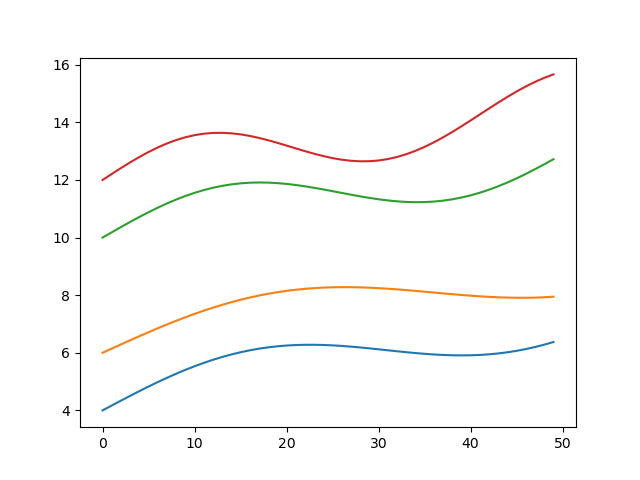

In [3]:
plt.figure()

x = np.linspace(0,60)

plt.plot(np.sin(x/12)+x/18+4)
plt.plot(np.sin(x/14)+x/21+6)

plt.plot(np.sin(x/10)+x/20+10)
plt.plot(np.sin(x/8)+x/22+12)



In [4]:

# In XY direction

x = np.linspace(0, 60, 60)
y = np.linspace(0, 60, 60)

xx = np.linspace(-10, 50, 60)
yy = np.linspace(-10, 50, 60)

# sources positions
#src_x = np.arange(0,40,1)
#src_y = src_x.copy()

X, Y = np.meshgrid(x, y) 

def cxy(x,y):

    ci = []
    
    xx = np.hstack(x)
    yy = np.hstack(y)

    for xi,yi in zip(xx,yy):

        if yi > (2*np.sin(xi/6)+xi/4+35):
            ci.append(1)

        elif yi > (1.5*np.sin(xi/4)+xi/5+30):
            ci.append(2)

        elif yi > (2*np.sin(xi/5)+xi/4.5+15):
            ci.append(3)

        elif yi > (1.5*np.sin(xi/6)+xi/6+12):
            ci.append(4)

        else:
            ci.append(1)
                   

    c = np.array(ci).reshape(np.shape(x))
    return c


cxy = cxy(X,Y)

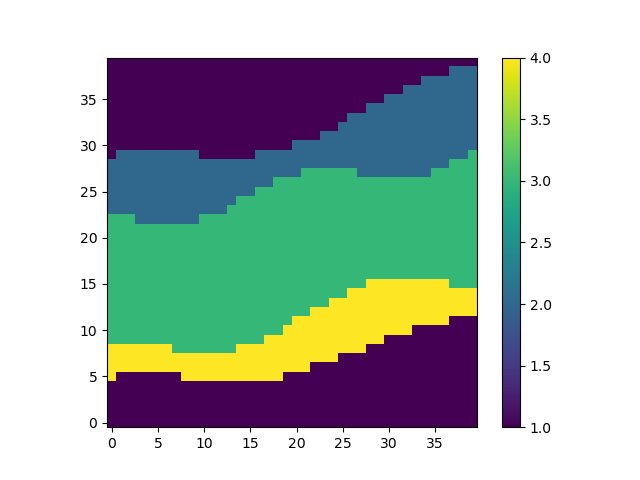

In [5]:
fig, ax = plt.subplots()
c = ax.imshow(cxy[10:50,10:50])
ax.invert_yaxis()
fig.colorbar(c)
plt.show()

In [6]:
cxy.shape

(60, 60)

In [7]:
# Create 2 layered models

#cxy = cxy.T
s_p = 10/1000
s_g = 100/1000
s_c = 50/1000
s_f = 30/1000

slope1 = 1/3
slope2 = -1/5

b1 = -1.2
b2 = +8

m = []

for i in range(cxy.shape[0]):
    for j in range(cxy.shape[1]):
        if cxy[i,j] == 3: # channel
            h = 3
            s1 = s_c
            s2 = s_g
            m.append([h, s1, s2])
        if cxy[i,j] == 1: # plain
            h = 2
            s1 = s_p
            s2 = s_g
            m.append([h, s1, s2])
        if cxy[i,j] == 4: # bars
            h = 2 + Y[i,j]/20 
            s1 = s_f
            s2 = s_g
            m.append([h, s1, s2])
        if cxy[i,j] == 2: # bars
            h = 3.5 - Y[i,j]/40
            s1 = s_f
            s2 = s_g
            m.append([h, s1, s2])
            

In [8]:
Y[i,j]/15

4.0

In [9]:
m = np.array(m).reshape(60,60,3)

<Axes: >

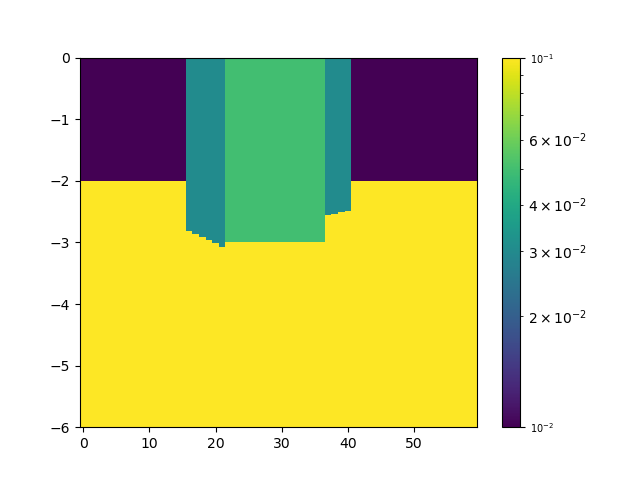

In [10]:
showStitchedModels(models = m[:,30,:], zMax= 6)

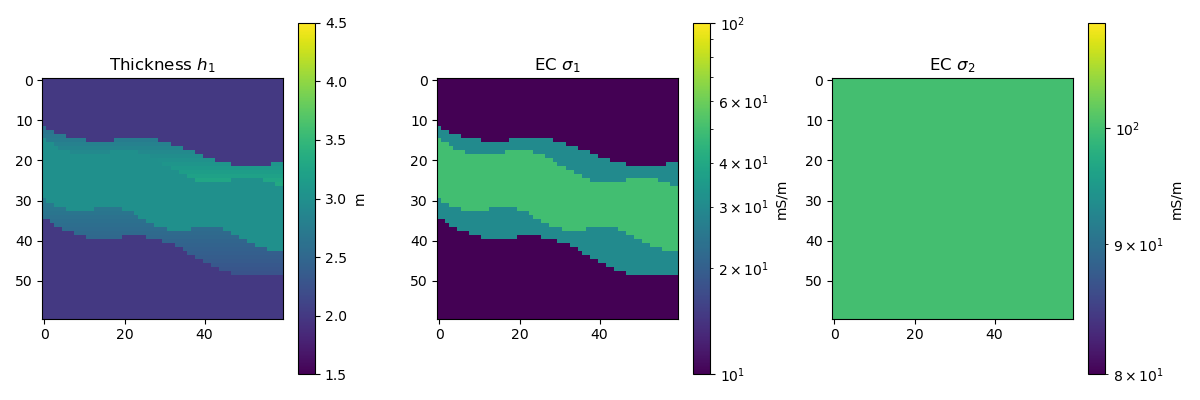

In [11]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(m[:,:,0], vmin=1.5, vmax=4.5)
fig.colorbar(c1, ax=ax[0], label='m',)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(m[:,:,1]*1000, vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m')
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(m[:,:,2]*1000, vmin =80, vmax=110, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m')
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

In [12]:
# Save model

np.save('models/model_3DChannel_new', m[10:50,10:50,:])

In [13]:
np.save('models/model_3DChannel_new_full.npy', m)

# Populate 3D mesh


  TensorMesh: 6,291,456 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    256   -120,626.29    151,095.18      0.20 30,458.88    1.25
   y     96   -101,254.79    151,878.44      0.20 50,623.65    1.50
   z    256     -1,026.49    103,268.66      0.10 33,000.26    1.47




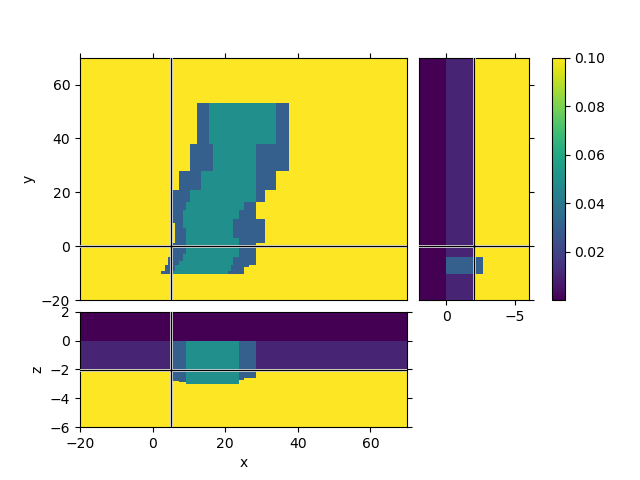

CPU times: user 5min 10s, sys: 9.98 s, total: 5min 20s
Wall time: 5min 22s


In [15]:
%%time

## 0. Define instrument settings

height = 0.15
frequency = 9000
n_workers = 20

# 1. Load model

# model with air layer

depths_air = m[:,:,0].copy() * 0
depths = np.stack((depths_air, -m[:,:,0]), axis=2)

sigmas_1 = m[:,:,1]
sigmas_2 = m[:,:,2]

# 2. Create a mesh

# Define a homogoneous model
sig = np.array([100/1000])
thk = np.array([])

# Insert air layer
sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))

src_x = 0
src_y = 0

# mesh
mesh = emg3d.construct_mesh(frequency = frequency,
                         properties = [20/1000, 20/1000, sig_3d[0]],
                         center = [src_x, src_y, height],
                         mapping='Conductivity',
                         domain = ([src_x-10, src_x+20],[src_y-10, src_y+10],[-10,10]),
                         min_width_limits = [0.2, 0.2, 0.1], # changed z from 0.1 to 0.2
                         center_on_edge=False,
                         stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                         lambda_from_center=True,
                         lambda_factor=3, 
                         )

print(mesh)
# 3. Populate mesh

# Define air layer
sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array

# Fill y-axis for y < 0

x = np.ones_like(mesh.cell_centers[:,0], dtype=bool)  
y = np.ones_like(mesh.cell_centers[:,1], dtype=bool) 
z_lay1 = (mesh.cell_centers[:,2] < depths[0,0,0]) & (mesh.cell_centers[:,2] > depths[0,0,1])
z_lay2 = (mesh.cell_centers[:,2] < depths[0,0,1]) 

sig_x[x*y*z_lay1] = m[0,0,1] # First layer sigma
sig_x[x*y*z_lay2] = m[0,0,2] # Second layer sigma

# Fill internal positions

for i in range(len(xx)-1):
    for j in range(len(yy)-1):
   
        x = (mesh.cell_centers[:,0] >= xx[i]) & (mesh.cell_centers[:,0] < xx[i+1])
        y = (mesh.cell_centers[:,1] >= yy[j]) & (mesh.cell_centers[:,1] < yy[j+1])
        z_lay1 = (mesh.cell_centers[:,2] < depths[i,j,0]) & (mesh.cell_centers[:,2] > depths[i,j,1])
        z_lay2 = (mesh.cell_centers[:,2] < depths[i,j,1]) 
    
        sig_x[x*y*z_lay1] = m[i,j,1]
        sig_x[x*y*z_lay2] = m[i,j,2]

#  4. Define models

Model = emg3d.Model(mesh, 
                 property_x = sig_x,
                 mapping = 'Conductivity')

Model_air = emg3d.Model(mesh,
                     property_x = sig_air,
                     mapping = 'Conductivity')

mesh.plot_3d_slicer(Model.property_x, zslice=-2, xlim=[-20,70], ylim = [-20,70], zlim=[-6,2], )

In [20]:
## 0. Define instrument settings

height = 0.15
frequency = 9000
n_workers = 20

# 1. Load model

# model with air layer

depths_air = m[:,:,0].copy() * 0
depths = np.stack((depths_air, -m[:,:,0]), axis=2)

sigmas_1 = m[:,:,1]
sigmas_2 = m[:,:,2]

# 2. Create a mesh

# Define a homogoneous model
sig = np.array([100/1000])
thk = np.array([])

# Insert air layer
sig_3d = np.hstack(([1/1e6], sig))
depth_3d = np.hstack(([0], -np.cumsum(thk)))


def ForwardChannel(src_x, src_y):

    # mesh
    mesh = emg3d.construct_mesh(frequency = frequency,
                             properties = [20/1000, 20/1000, sig_3d[0]],
                             center = [src_x, src_y, height],
                             mapping='Conductivity',
                             domain = ([src_x-10, src_x+20],[src_y-10, src_y+10],[-10,10]),
                             min_width_limits = [0.2, 0.2, 0.1], # changed z from 0.1 to 0.2
                             center_on_edge=False,
                             stretching= {'x': [1,1.5], 'y': [1.1,1.5], 'z': [1,1.5]}, 
                             lambda_from_center=True,
                             lambda_factor=3, 
                             )

    print(mesh)
    # 3. Populate mesh
    
    # Define air layer
    sig_x = np.ones(mesh.n_cells)*sig_3d[0] # empty array to be populated
    sig_air = np.ones(mesh.n_cells)*sig_3d[0] # air array

    # Fill y-axis for y < 0
    
    x = np.ones_like(mesh.cell_centers[:,0], dtype=bool)  
    y = np.ones_like(mesh.cell_centers[:,1], dtype=bool) 
    z_lay1 = (mesh.cell_centers[:,2] < depths[0,0,0]) & (mesh.cell_centers[:,2] > depths[0,0,1])
    z_lay2 = (mesh.cell_centers[:,2] < depths[0,0,1]) 
    
    sig_x[x*y*z_lay1] = m[0,0,1] # First layer sigma
    sig_x[x*y*z_lay2] = m[0,0,2] # Second layer sigma
    
    # Fill internal positions
    
    for i in range(len(xx)-1):
        for j in range(len(yy)-1):
       
            x = (mesh.cell_centers[:,0] >= xx[i]) & (mesh.cell_centers[:,0] < xx[i+1])
            y = (mesh.cell_centers[:,1] >= yy[j]) & (mesh.cell_centers[:,1] < yy[j+1])
            z_lay1 = (mesh.cell_centers[:,2] < depths[i,j,0]) & (mesh.cell_centers[:,2] > depths[i,j,1])
            z_lay2 = (mesh.cell_centers[:,2] < depths[i,j,1]) 
        
            sig_x[x*y*z_lay1] = m[i,j,1]
            sig_x[x*y*z_lay2] = m[i,j,2]
    
    #  4. Define models
    
    Model = emg3d.Model(mesh, 
                     property_x = sig_x,
                     mapping = 'Conductivity')
    
    Model_air = emg3d.Model(mesh,
                         property_x = sig_air,
                         mapping = 'Conductivity')

    #mesh.plot_3d_slicer(Model.property_x, zslice=-2, xlim=[-20,60], ylim = [-20,60], zlim=[-6,2], )
    
    print('Defining geometry')
    # Define source coordinates
    
    Hsrc_coords = [src_x, src_y, height, 0, 90]
    Vsrc_coords = [src_x, src_y, height, 90, 0]
    print('source:', Hsrc_coords)
    
    # Define H and V receivers coordinates
    offsets_HV = np.array([src_x+2, src_x+4, src_x+8])
    #print('offsets:',offsets_HV)
    #rec_coords = [offsets_HV, offsets_HV*0, np.ones_like(offsets_HV)*height, azi, dip]
    
    # Define P receivers coordinates
    offsets_P = np.array([src_x+2.1, src_x+4.1, src_x+8.1])
    #rec_coords_p = [offsets_P, offsets_P*0, np.ones_like(offsets_P)*height, azi, dip]
    
    # Define sources
    Hsource = emg3d.TxMagneticPoint(Hsrc_coords)
    Vsource = emg3d.TxMagneticPoint(Vsrc_coords)
    
    # Solve Electrical fields
    #print('Solving sources...')
    # Total field Hsource
    Efield_H = emg3d.solve_source(model = Model, source = Hsource, frequency = frequency)
    # Primary field Hsource
    Efield_H_p = emg3d.solve_source(model = Model_air, source = Hsource, frequency = frequency)
    
    # Total field Vsource
    Efield_V = emg3d.solve_source(model = Model, source = Vsource, frequency = frequency)
    # Primary field Vsource
    Efield_V_p = emg3d.solve_source(model = Model_air, source = Vsource, frequency = frequency)

    # Get magnetic fields
   # print('getting magnetic fields...')
    # Total magnetic field Hsource
    Hfield_H = emg3d.get_magnetic_field(model = Model, efield = Efield_H)
    # Primary magnetic field Hsource
    Hfield_H_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_H_p)
    
    # Total magnetic field Vsource
    Hfield_V = emg3d.get_magnetic_field(model = Model, efield = Efield_V)
    # Primary magnetic field Vsource
    Hfield_V_p = emg3d.get_magnetic_field(model = Model_air, efield = Efield_V_p)
    
    # Get fields at receivers
  #  print('magnetic field at receivers...')
    # For total field Hsource
    H_Hrec = Hfield_H.get_receiver((offsets_HV, np.ones_like(offsets_HV)*src_y, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # For primary field Hsource
    H_Hrec_p = Hfield_H_p.get_receiver((offsets_HV, np.ones_like(offsets_HV)*src_y, height, 0, 90))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Hsource
    H_Hrec_s = H_Hrec - H_Hrec_p
    
    # For total field Vsource
    H_Vrec = Hfield_V.get_receiver((offsets_HV, np.ones_like(offsets_HV)*src_y, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Vsource
    H_Vrec_p = Hfield_V_p.get_receiver((offsets_HV, np.ones_like(offsets_HV)*src_y, height, 90, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Vsource
    H_Vrec_s = H_Vrec - H_Vrec_p
    
    # For total field Psource
    H_Prec = Hfield_H.get_receiver((offsets_P, np.ones_like(offsets_P)*src_y, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # For primary field Psource in xz direction
    H_Prec_p_xz = Hfield_H_p.get_receiver((offsets_P, np.ones_like(offsets_P)*src_y, height, 0, 0))*(2j * np.pi * frequency * mu_0) 
    # Secondary field Psource
    H_Prec_s = H_Prec - H_Prec_p_xz
    # Primary field Psource in zz direction
    H_Prec_p = Hfield_H_p.get_receiver((offsets_P, np.ones_like(offsets_P)*src_y, height, 0, 90))*(2j * np.pi * frequency * mu_0)
    
     # Calculate output components OP and IP
 #   print('getting output components')
    # Horizontal coplanar
    op_h = (H_Hrec_s/H_Hrec_p).imag.amp()
    ip_h = (H_Hrec_s/H_Hrec_p).real.amp()
    #OUT.append([op_h, ip_h])
    # Vertical coplanar
    op_v = (H_Vrec_s/H_Vrec_p).imag.amp()
    ip_v = (H_Vrec_s/H_Vrec_p).real.amp()
    #OUT.append([op_v, ip_v])
    # Perpendicular
    op_p = (H_Prec_s/H_Prec_p).imag.amp()
    ip_p = (H_Prec_s/H_Prec_p).real.amp()
    #OUT.append([op_p, ip_p])
    
    OUT_i = pd.DataFrame({'geom'  : ['H2', 'H4', 'H8', 'V2', 'V4', 'V8', 'P2', 'P4', 'P8'],
                          'src_x' : [Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0],
                                     Vsrc_coords[0], Vsrc_coords[0], Vsrc_coords[0],
                                     Hsrc_coords[0], Hsrc_coords[0], Hsrc_coords[0]],
                          'src_y' : [Hsrc_coords[1], Hsrc_coords[1], Hsrc_coords[1],
                                     Vsrc_coords[1], Vsrc_coords[1], Vsrc_coords[1],
                                     Hsrc_coords[1], Hsrc_coords[1], Hsrc_coords[1]],
                          'rec_x' : np.hstack((offsets_HV, offsets_HV, offsets_P)),
                          'rec_y' : [Hsrc_coords[1], Hsrc_coords[1], Hsrc_coords[1],
                                     Vsrc_coords[1], Vsrc_coords[1], Vsrc_coords[1],
                                     Hsrc_coords[1], Hsrc_coords[1], Hsrc_coords[1]],
                          'midpx' : np.hstack((Hsrc_coords[0] + (offsets_HV - Hsrc_coords[0])/2,
                                               Vsrc_coords[0] + (offsets_HV - Vsrc_coords[0])/2,
                                               Hsrc_coords[0] + (offsets_P - Hsrc_coords[0])/2)),
                          'op'    : np.hstack((op_h, op_v, op_p)),
                          'ip'    : np.hstack((ip_h, ip_v, ip_p)) 
                          })
    
    #OUT = pd.concat([OUT, OUT_i], ignore_index=True)
    print()
    return OUT_i, mesh, Model

In [22]:
startTime = time.time()

d, mesh, Model = ForwardChannel(30, 30)

endTime = time.time()
print()
print('Done in', (endTime - startTime), 'seconds!')


  TensorMesh: 6,291,456 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    256   -120,596.29    151,125.18      0.20 30,458.88    1.25
   y     96   -101,224.79    151,908.44      0.20 50,623.65    1.50
   z    256     -1,026.49    103,268.66      0.10 33,000.26    1.47


Defining geometry
source: [30, 30, 0.15, 0, 90]


Done in 2612.1371669769287 seconds!


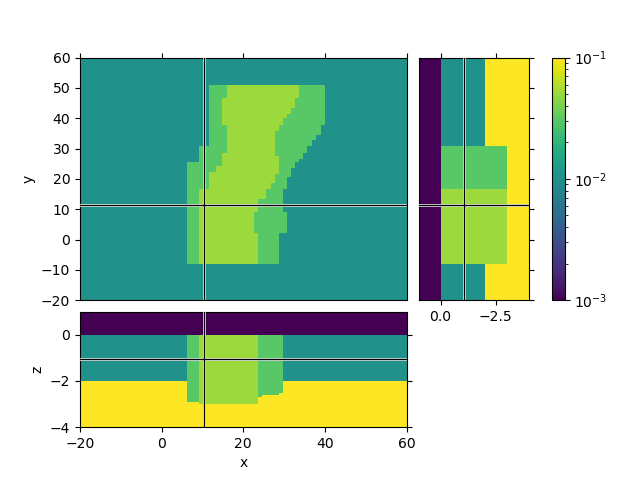

In [34]:
mesh.plot_3d_slicer(
    Model.property_x, xslice=10, yslice=10, zslice = -1, pcolor_opts=popts, xlim=[-20,60], ylim=[-20,60], zlim=[-4,1],
)

fig = plt.gcf()
ax = fig.get_children()
ax[1].plot(src_x, src_y, '*r')
ax[2].plot(src_x, height, '*r')